# INF8111 - Fouille de données


## TP1 AUTOMNE 2025 - Préparation de données




### Instructions de remise

#### Membres de l'équipe :
    - Nom (Matricule) 1
    - Nom (Matricule) 2
    - Nom (Matricule) 3

#### Numéro du groupe :
    - TP - Groupe #
    
#### Livrable :

Vous devez soumettre ce notebook sur Moodle dans la boite de remise sous le nom TP1_NumeroGroupe_matricule1_matricule2_matricule3.ipynb .

**NB**: Tout travail en retard sera pénalisé d'une valeur de 10\% par jour de retard.


## Introduction et objectifs

### Importation des différents modules

In [1]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib
!pip install plotly
!pip install shap

In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn import linear_model
import shap

### Lecture des données

In [3]:
df = pd.read_csv('data.csv')

Le but de ce notebook est d'effectuer le prétraitement du dataset [HousePricePrediction](https://docs.google.com/spreadsheets/d/1caaR9pT24GNmq3rDQpMiIMJrmiTGarbs/edit#gid=1150341366) qui pourra être par la suite être utilisé pour entraîner un modèle de prédiction de prix de maisons.

## Préparation des données

Plusieurs étapes sont nécessaires pour préparer un dataset pour la fouille des données
- **Nettoyage des données** :
    - Suppression des attributs inutiles
    - Gestion des valeurs manquantes
    - Gestion des valeurs aberrantes
- **Transformation des données** :
    - Encodage des données
    - Normalisation des données
- **Sélection des attributs** :
    - Suppression des attributs les plus fortement corrélés

<a id="exploration-des-donnees"></a>
## 1. Exploration des données (5 points)

Nous vous avons fourni le fichier *data.csv* avec l'exécution de la deuxième cellule. Il contient l'ensemble des données. Chaque ligne contient les données d'une vente. La description des attributs du dataset est la suivante:

| # | Feature Name | Description |
|---|--------------|-------------|
| 1 | Id           | Numéro de vente / To count the records. |
| 2 | MSSubClass   | Type de logement / Identifies the type of dwelling involved in the sale. |
| 3 | MSZoning     | Zonage / Identifies the general zoning classification of the sale. |
| 4 | LotArea      | Superficie du logement / Lot size in square feet. |
| 5 | LotConfig    | Configuration du logement / Configuration of the lot |
| 6 | BldgType     | Type de logement / Type of dwelling |
| 7 | OverallCond  | Etat général / Rates the overall condition of the house |
| 8 | YearBuilt    | Année de contruction / Original construction year |
| 9 | YearRemodAdd | Année de rénovation / Remodel date (same as construction date if no remodeling or additions). |
| 10| Exterior1st  | Type de revêtement extérieur / Exterior covering on house |
| 11| BsmtFinSF2   | Surface de vie / Type 2 finished square feet. |
| 12| TotalBsmtSF  | Surface totale de la base / Total square feet of basement area |
| 13| SalePrice    | Prix de vente à prédire / To be predicted |

On visualise le dataset pour avoir une idée de ce qu'il contient et des prétraitements à effectuer.

### 1.1 - Question 1 (2.5 points)

**Combien d'observations contient le dataset ? Quelles sont les types des attributs du dataset ?**

In [4]:

num_observations = len(df)
print(f"Nombre d'observations: {num_observations}")

print("\nLes types des attributs du dataset :")
print(df.dtypes)

Nombre d'observations: 2919

Les types des attributs du dataset :
Id                int64
MSSubClass        int64
MSZoning         object
LotArea           int64
LotConfig        object
BldgType         object
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
Exterior1st      object
BsmtFinSF2      float64
TotalBsmtSF     float64
SalePrice       float64
dtype: object


### 1.2 - Question 2 (2.5 points)

**Quelles sont les valeurs uniques des attributs de type `object` ?**

In [5]:
# Identify columns with 'object' data type
object_columns = df.select_dtypes(include=['object']).columns

# Print unique values for each object column
print("Les valeurs uniques des attributs de type 'object':")
for column in object_columns:
    unique_values = df[column].unique()
    print(f"{column}: {unique_values}")

Les valeurs uniques des attributs de type 'object':
MSZoning: ['RL' 'RM' 'C (all)' 'FV' 'RH' nan]
LotConfig: ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
BldgType: ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
Exterior1st: ['VinylSd' 'MetalSd' 'Wd Sdng' 'HdBoard' 'BrkFace' 'WdShing' 'CemntBd'
 'Plywood' 'AsbShng' 'Stucco' 'BrkComm' 'AsphShn' 'Stone' 'ImStucc'
 'CBlock' nan]


<a id="nettoyage-des-donnees"></a>
## 2. Nettoyage des données (30 points)

<a id="suppression-des-attributs-inutiles"></a>
### 2.1 Suppression des attributs inutiles

### 2.1.1 - Question 3 (5 points)

**Pourquoi on peut supprimer l'attribut `Id` dans le cas de ce TP? Effectuez cette suppression.**

#Réponse

In [6]:
# Remove the 'Id' column
df = df.drop(columns=['Id'])

# Verify the column has been removed
print("Columns after removing 'Id':", df.columns.tolist())

Columns after removing 'Id': ['MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']


<a id="gestion-des-valeurs-manquantes"></a>
### 2.2 Gestion des valeurs manquantes

Pour gérer les valeurs manquantes, plusieurs solutions s'offrent à nous :
- Remplacer par la valeur la plus fréquente (le mode)
- Remplacer par la valeur moyenne/médiane
- Suppression des lignes contenant des valeurs manquantes

Pour ce TP, nous optons pour la dernière option.

#### 2.2.1 - Question 4 (2.5 points)

**Quels sont les attributs qui contiennent des valeurs manquantes ?**

In [7]:
print("Missing values per attribute:")
missing_values = df.isnull().sum()
print(missing_values)

Missing values per attribute:
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64


#### 2.2.2 - Question 5 (2.5 points)

On peut alors gérer les valeurs manquantes colonne par colonne. L'attribut `SalePrice` n'est pas pris en considération car les valeurs manquantes sont justement les valeurs que nous voulons prédire.

**Supprimer les lignes contenant les valeurs manquantes. Implémentez la fonction `delete_missing_values` qui retire ces données**.

In [9]:
def delete_missing_values(dataset):
    """
    This function deletes row whom a value is missing.

    :param dataset: ensemble des données
    :return:
      dataset traitée
    """
    columns_to_check = [col for col in dataset.columns if col != 'SalePrice']
    df_clean = dataset.dropna(subset=columns_to_check)

    return df_clean

In [10]:
print(f"\nNumber of rows before cleaning: {len(df)}")
df = delete_missing_values(df)
print(f"Number of rows after cleaning: {len(df)}")


Number of rows before cleaning: 2919
Number of rows after cleaning: 2913


Les données manquantes pour la colonne `SalePrice` sont celles du dataset de test. On laisse donc ces valeurs manquantes car on veut appliquer le même prétraitement sur les données de test.

### 2.2.3 - Question 6 (10 points)

On veut néanmoins que les données d'entrainement suivent une distribution gaussienne.

**Implémenter le fonction `plot_hist`. Cette fonction doit permettre d'afficher la distribution des valeurs de l'attribut `SalePrice` ainsi que la loi normale de même moyenne et variance.**

In [11]:
def plot_hist(prices, type=""):
    """
    Affiche la distribution du prix de vente

    :param prices: ensemble des prix.
    """

    prices = prices.dropna()
    mean_price = prices.mean()
    std_price = prices.std()

    # La distribution des valeurs
    plt.hist(prices, bins=30, density=True, alpha=0.7, color='blue', label='SalePrice Distribution')

    # La loi normale de même moyenne et variance
    x = np.linspace(prices.min(), prices.max(), 100)
    gaussian = (1 / (std_price * np.sqrt(2 * np.pi))) * np.exp(-((x - mean_price) ** 2) / (2 * std_price ** 2))

    plt.plot(x, gaussian, 'r-', label=f'Gaussian (mean={mean_price:.2f}, std={std_price:.2f})')
    if (type != "log"):
      plt.xlabel('SalePrice')
      plt.ylabel('Densité')
      plt.title('Distribution des valeurs de SalePrice et la loi normale')
    else:
      plt.xlabel('Log(SalePrice)')
      plt.ylabel('Densité')
      plt.title('Distribution des valeurs et la loi normale après une transformation logarithmique ')

    plt.legend()
    plt.show()

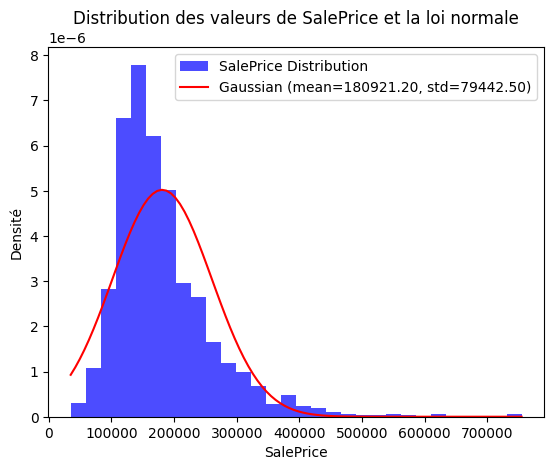

In [12]:
plot_hist(df['SalePrice'])

Vous devez obtenir une distribution des valeurs de `SalePrice` proches d'une distribution normale mais légèrement asymétrique. On peut alors appliquer une transformation logarithmique pour approcher d'une distribution normale symétrique.

**Effectuer cette transformation sur notre ensemble de données.**

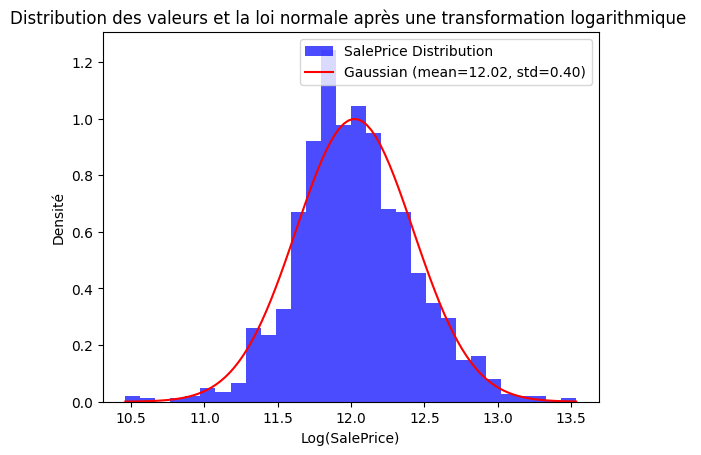

In [14]:
df['SalePrice'] = df['SalePrice'].apply(lambda x: np.log(x) if pd.notnull(x) else x)
plot_hist(df['SalePrice'], type ="log")

In [16]:
# Cette copie va servir plus tard pour la question 6 (IQR)
df_order1 = df.copy()

<a id="detection-des-valeurs-aberrantes"></a>
### 2.3 Détection des valeurs aberrantes

En pratique, la méthode de détection d'une valeur aberrante nécessite de se poser les questions suivantes:
- Quelles valeurs seraient incohérentes pour chaque colonne ?
- Quelles valeurs peuvent être problématiques pour l'utilisation de ces données ? Exemple: pour une régression linéaire, on préfère avoir des valeurs distribuées suivant une loi normale.

Avec ces éléments, on peut:
- Fixer des seuils de tolérance pour les valeurs aberrantes
- Utiliser des algorithmes de détection de valeurs aberrantes (ex: clustering, IRQ, [QTest](https://plotly.com/python/v3/outlier-test/), ...)

A noter que suivant les méthodes, les valeurs détectées comme aberrantes peuvent être différentes.

La méthode IRQ fait l'objet d'une question, en fin de ce notebook.

### 2.3.1 Question 7 (10 points)

Ici comme nous allons réaliser une régression linéaire, nous allons visuellement voir si certains points s'écartent largement de la droite de régression.

On sait que l'on veut effectuer une régression linéaire pour prédire `SalePrice`. On peut donc visualiser les valeurs de chaque attribut en fonction de `SalePrice` pour détecter la présence de valeurs aberrantes.

**Implémenter la fonction `plot_line`. Elle doit permettre de visualiser la relation entre un attribut donné et `SalePrice`.**

In [ ]:
def plot_line(attr):
    """
    Affiche la relation entre attr et SalePrice

    :param attr: attribut à comparer à SalePrice
    """
    mask = df[attr].notna() & df['SalePrice'].notna()
    x = df.loc[mask, attr].values.reshape(-1, 1)
    y = df.loc[mask, 'SalePrice'].values

    if len(x) == 0:
        print(f"No valid data for attribute '{attr}'")
        return


    # Create the plot
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.6, color='blue', label='Data points')

    # Add labels and title
    plt.xlabel(attr)
    plt.ylabel('SalePrice')
    plt.title(f'Relationship between {attr} and SalePrice')
    plt.legend()

    # Show plot
    plt.show()

**Afficher les relations de tous les attributs avec `SalePrice`. Peut-on y déceler des valeurs aberrantes ?**

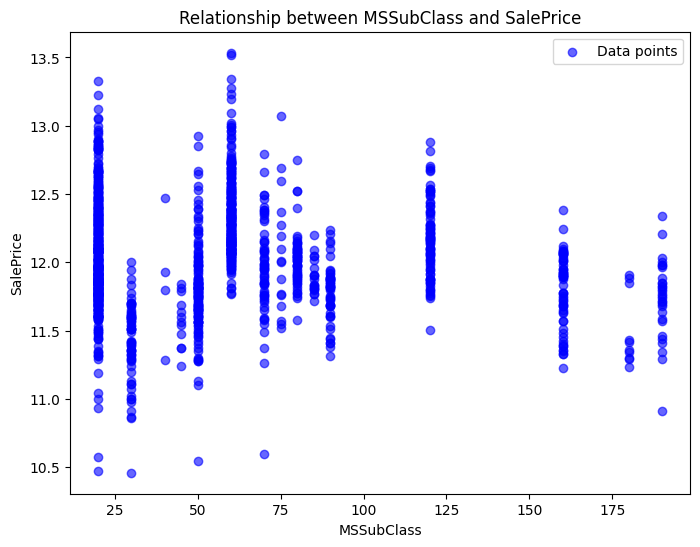

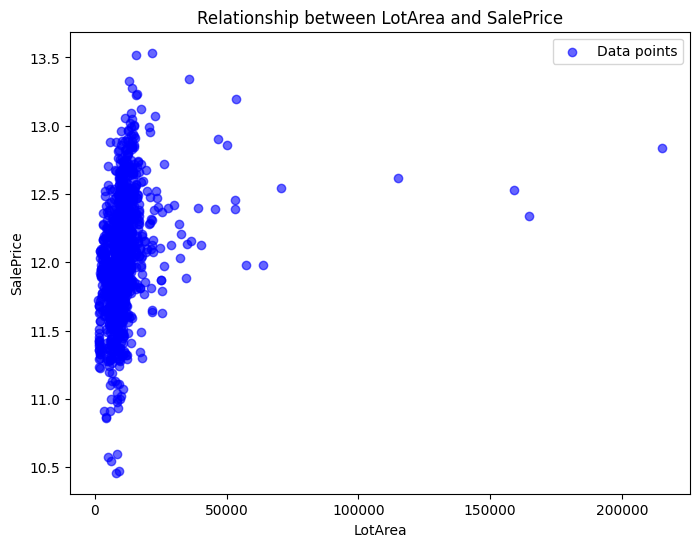

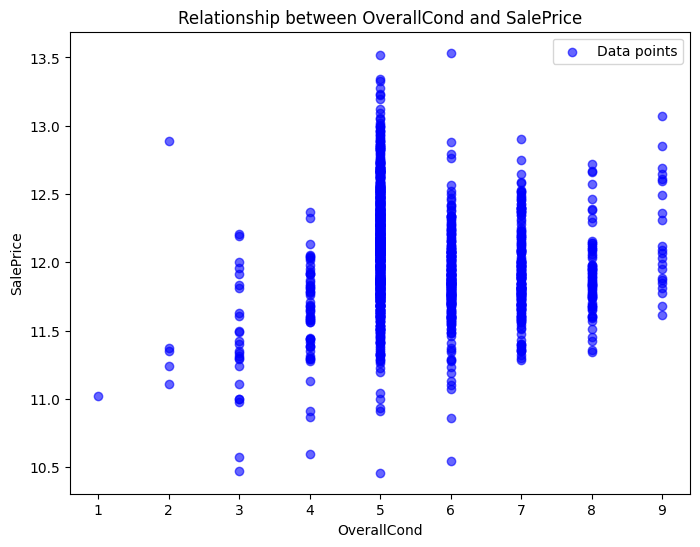

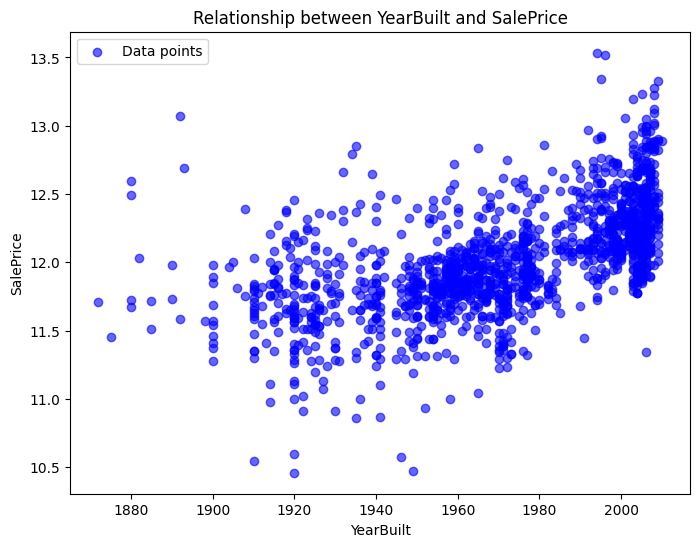

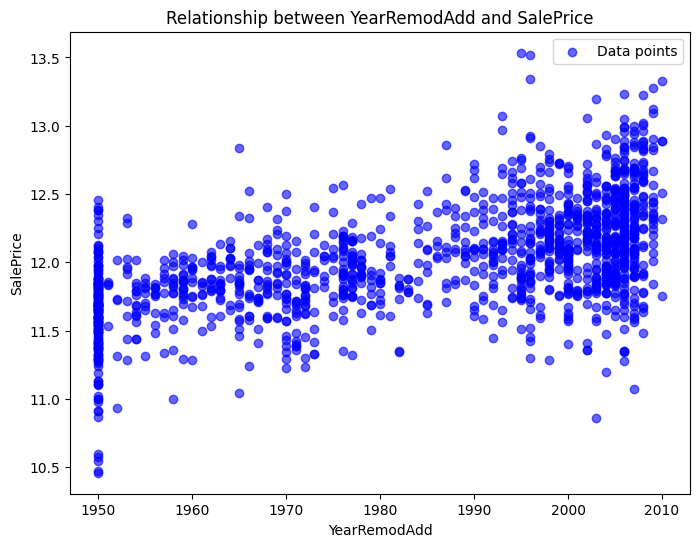

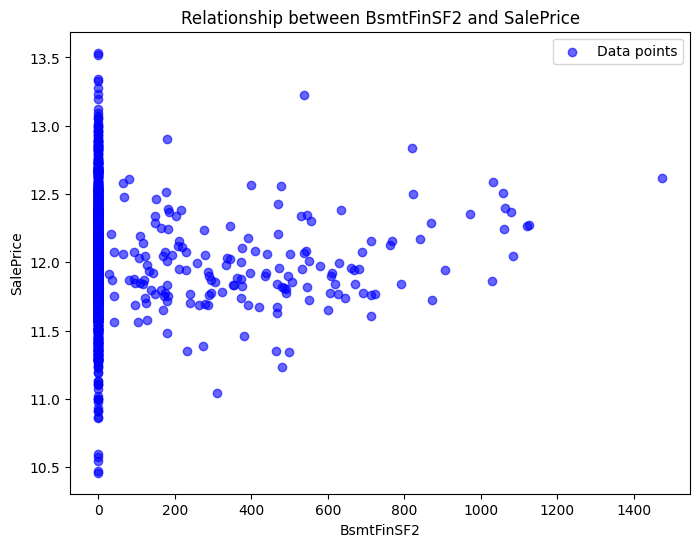

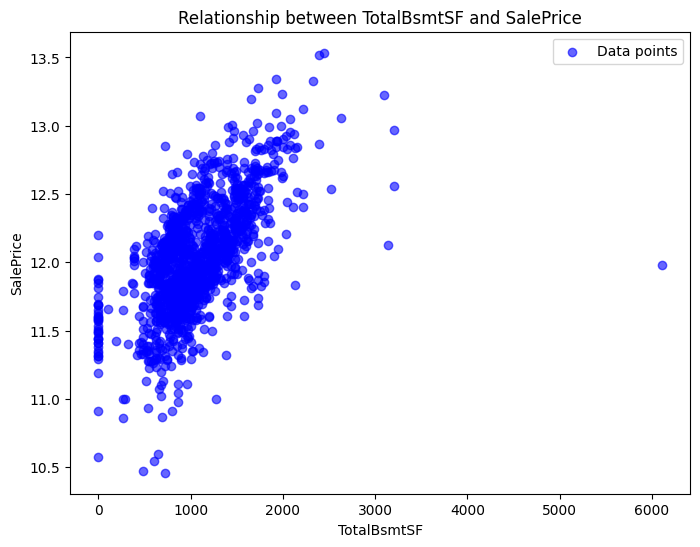

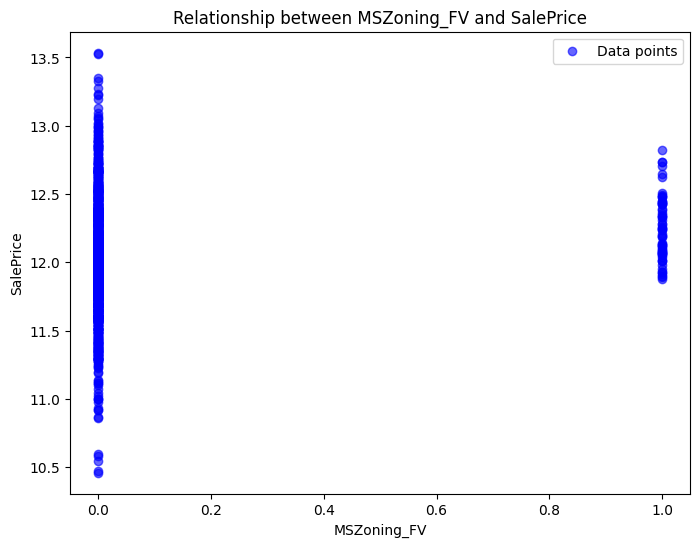

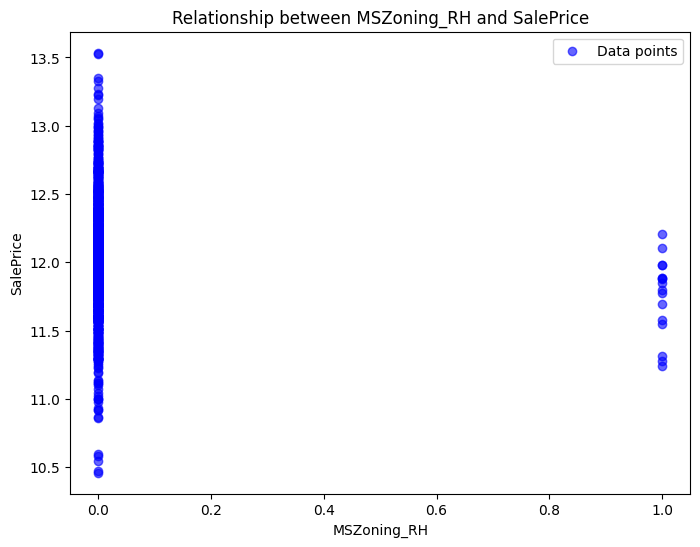

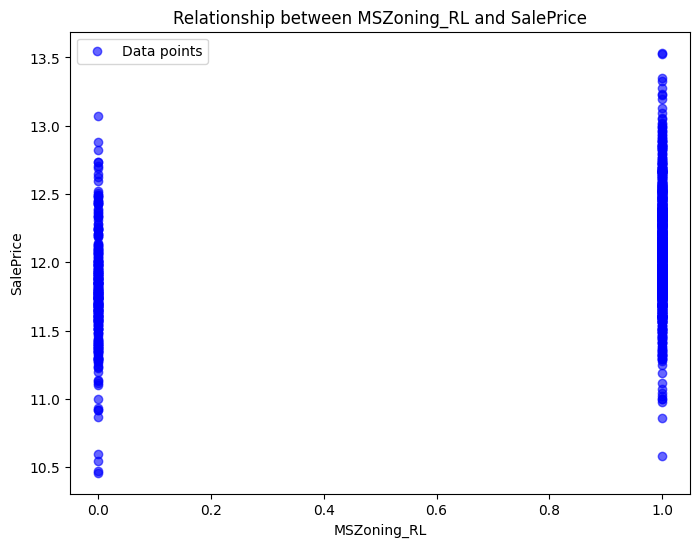

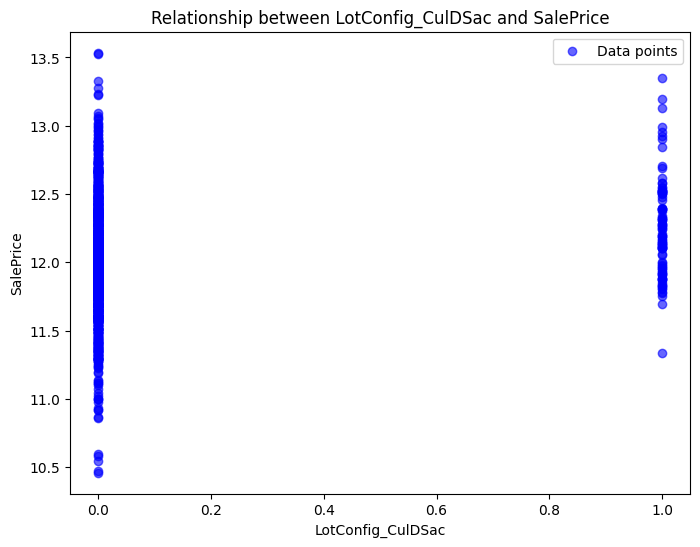

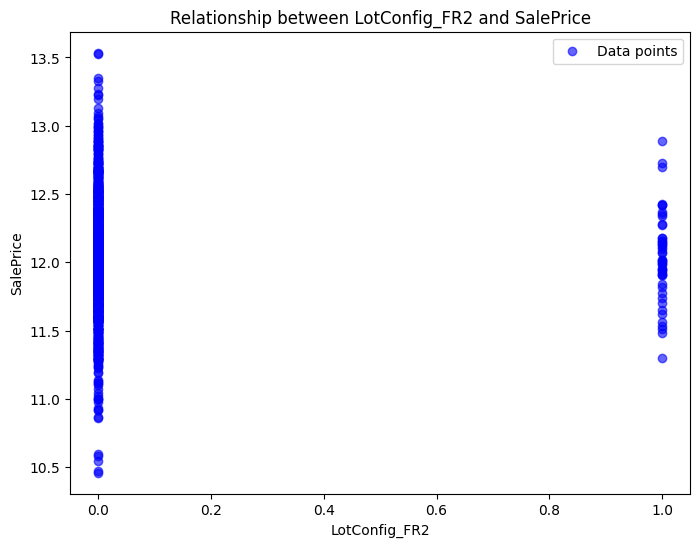

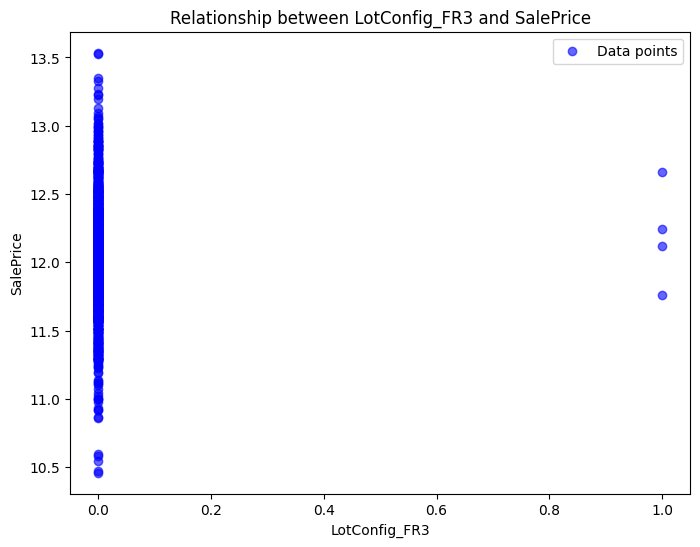

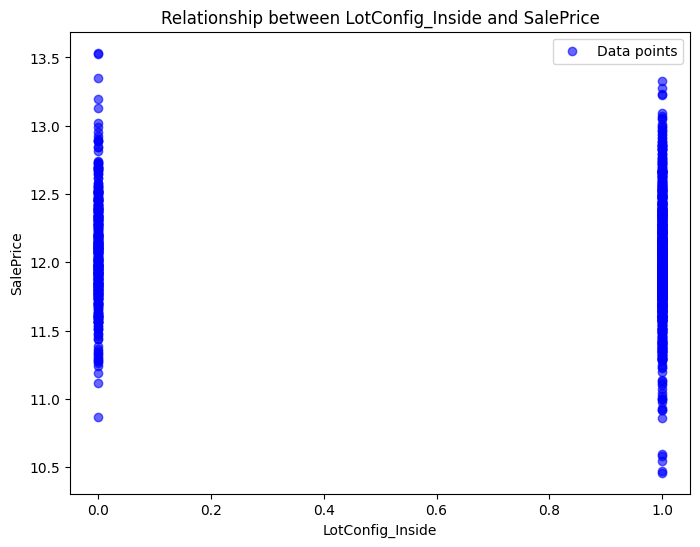

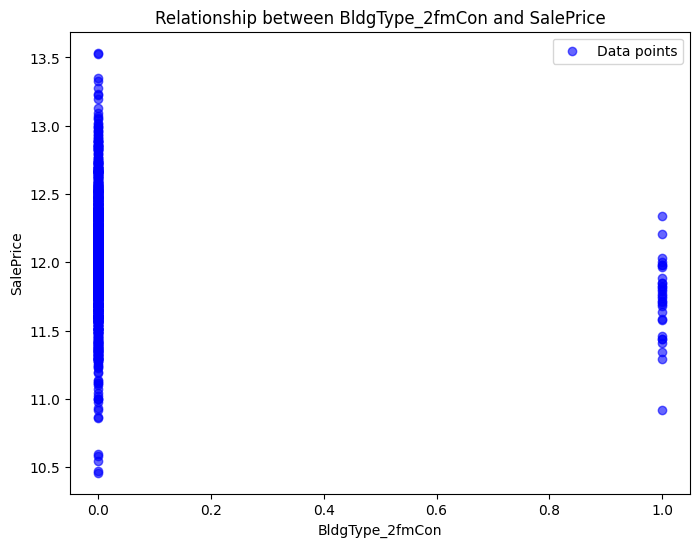

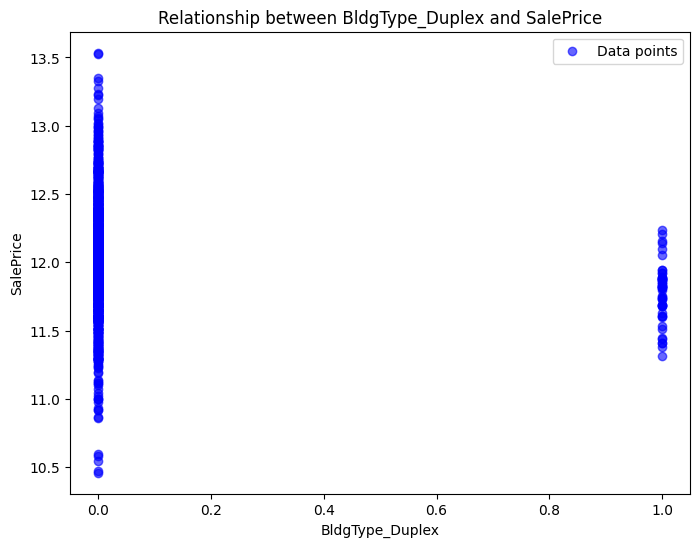

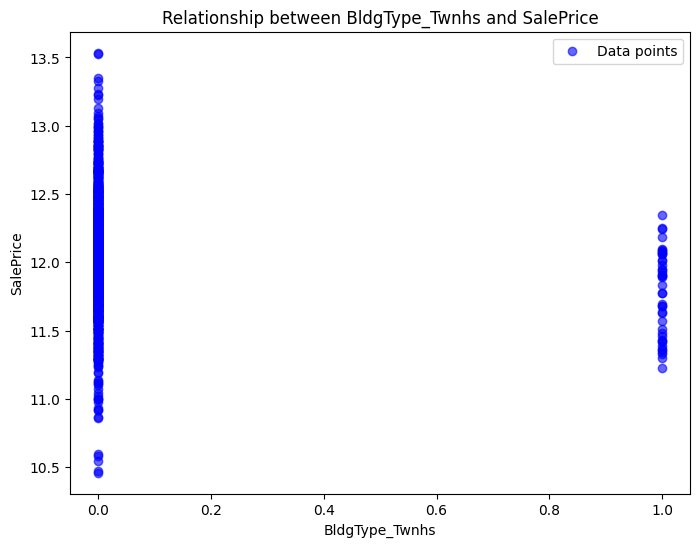

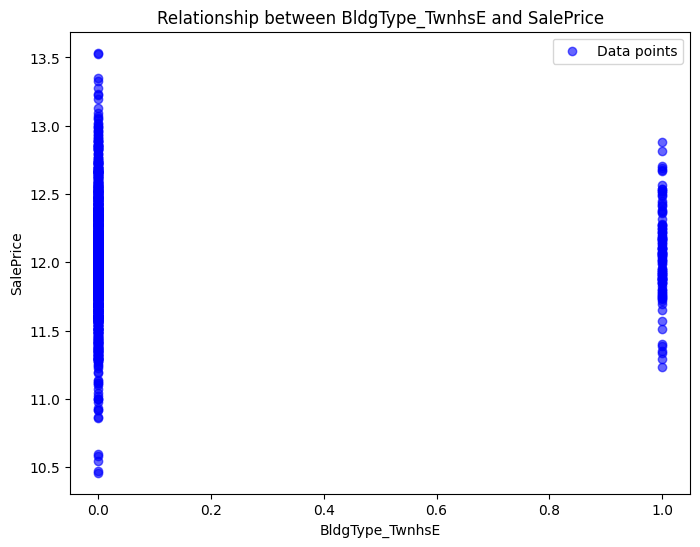

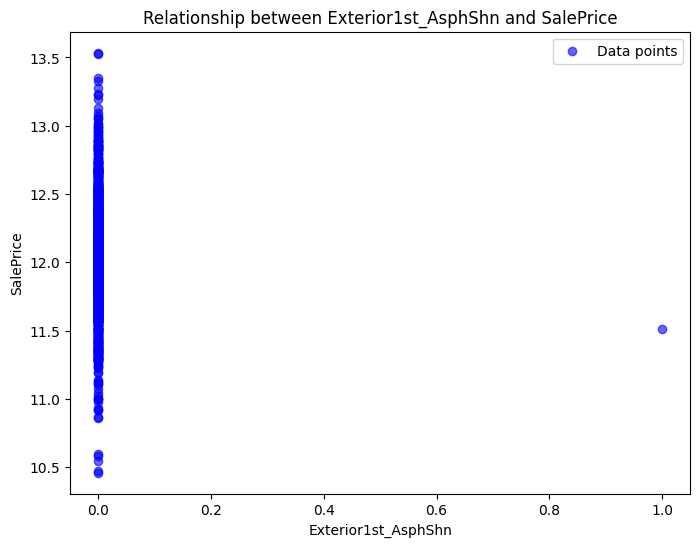

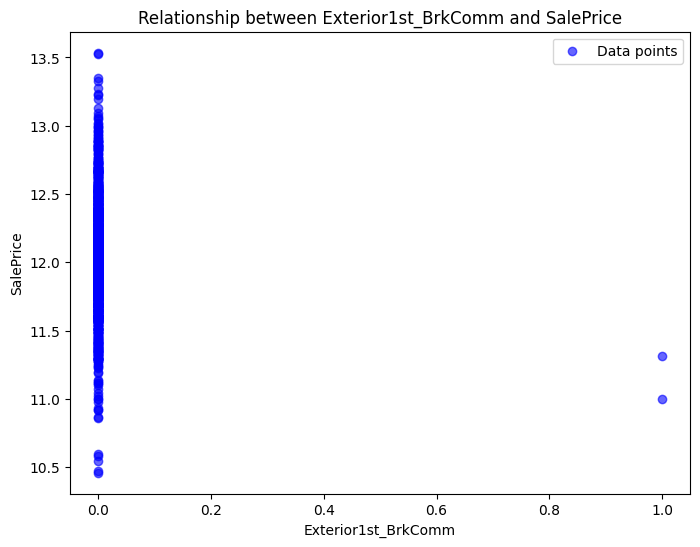

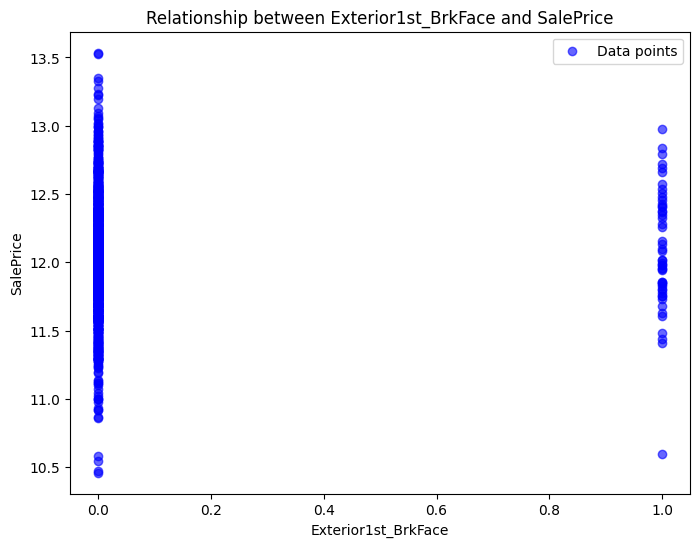

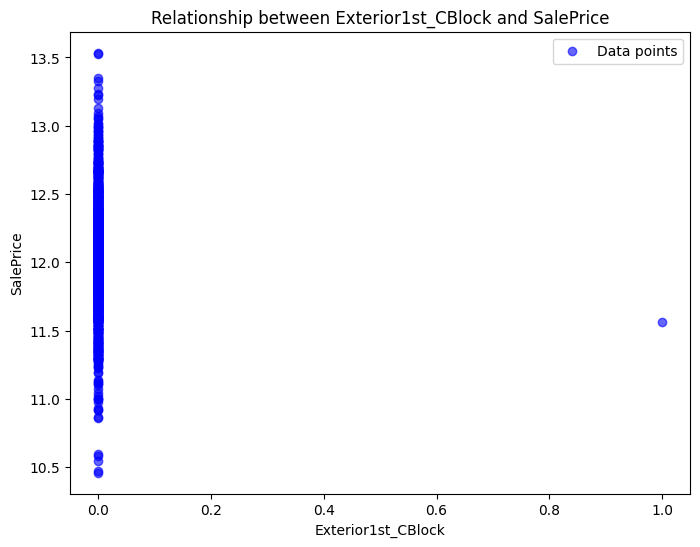

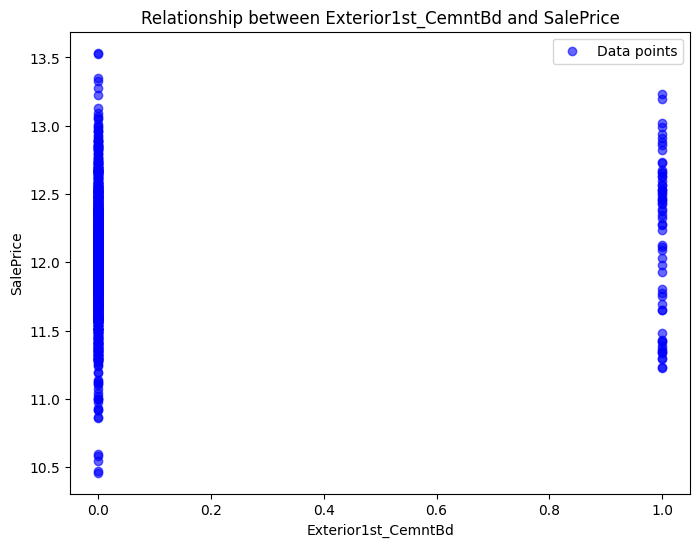

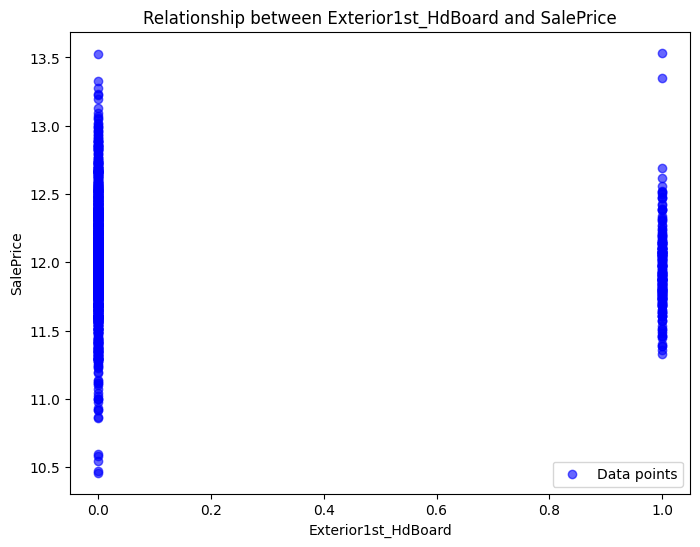

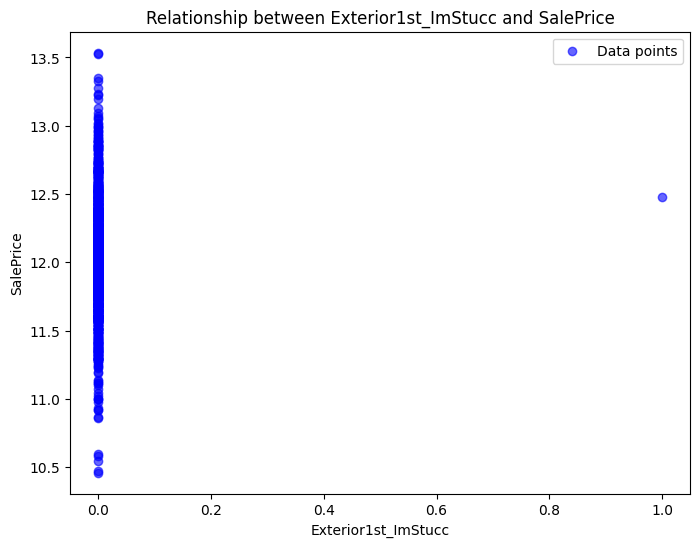

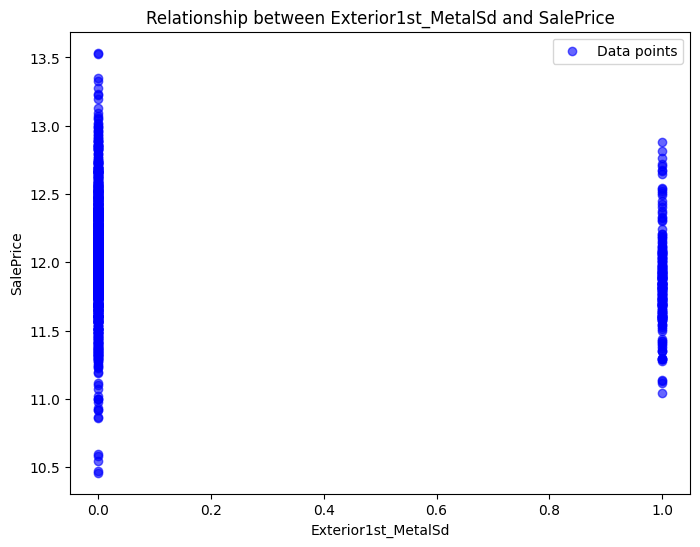

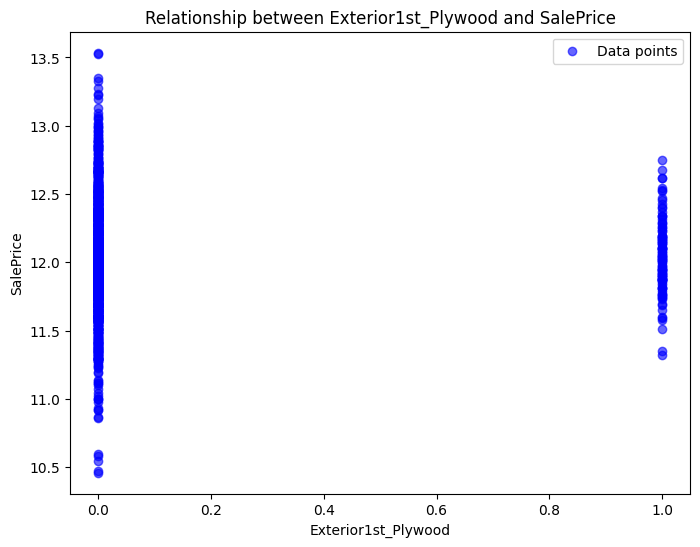

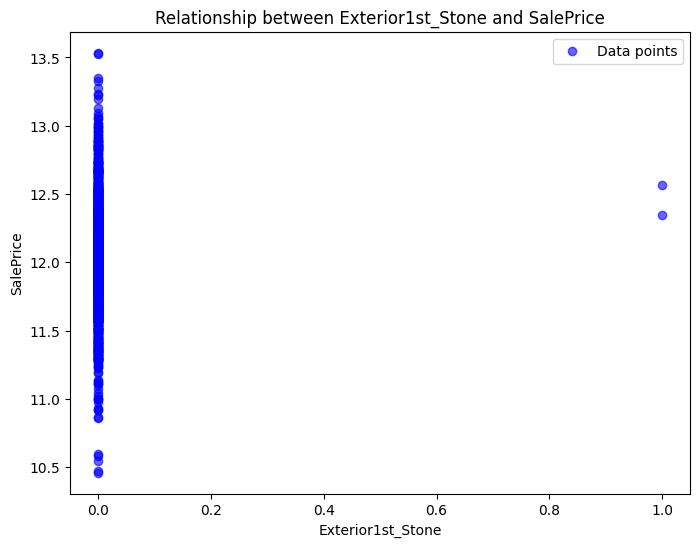

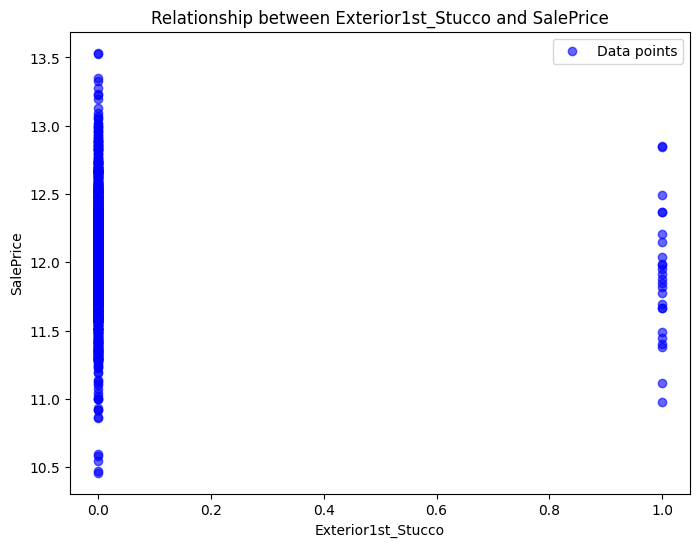

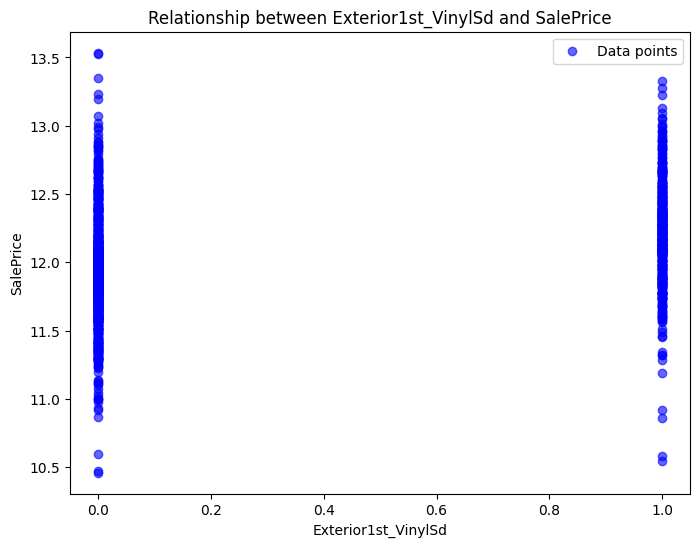

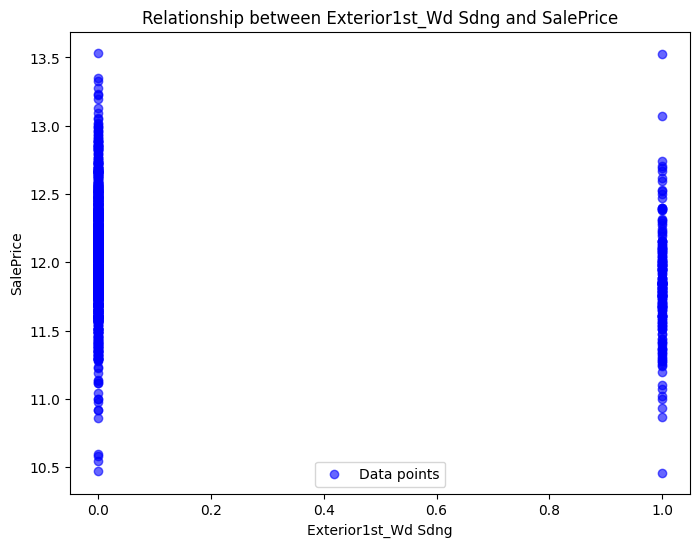

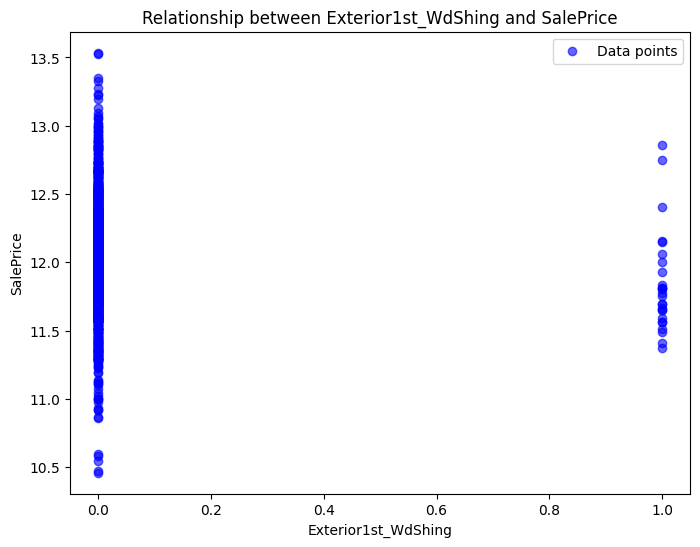

In [ ]:
attributes = [col for col in df.columns if col != 'SalePrice']

# Afficher les relations de tous les attributs
for attr in attributes:
    plot_line(attr)

**À ce stade, il s'agit uniquement de détecter la présence éventuelle de valeurs aberrantes dans les données.**
**Aucune action de traitement ou de remplacement n'est demandée pour le moment**

## 3. Transformation des données (10 points)

### 3.1 Encodage des attributs de type `object`

Les attributs de type `object` étant catégoriques (voire partie 1), on peut effectuer un `one hot encoding` de ces attributs. `Pandas` permet d'effectuer cela avec la fonction `get_dummies()`. Cela nous permettra d'obtenir un dataset contenant uniquement des attributs de type `int` ou `float`.


#### 3.1.1 Question 8 (5 points)

**Encodez les attributs de type `object` avec un `one hot encoding`**

In [18]:
object_columns = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=object_columns, prefix=object_columns, drop_first=True)

print(df.head())

   MSSubClass  LotArea  OverallCond  YearBuilt  YearRemodAdd  BsmtFinSF2  \
0          60     8450            5       2003          2003         0.0   
1          20     9600            8       1976          1976         0.0   
2          60    11250            5       2001          2002         0.0   
3          70     9550            5       1915          1970         0.0   
4          60    14260            5       2000          2000         0.0   

   TotalBsmtSF  SalePrice  MSZoning_FV  MSZoning_RH  ...  Exterior1st_CemntBd  \
0        856.0  12.247694        False        False  ...                False   
1       1262.0  12.109011        False        False  ...                False   
2        920.0  12.317167        False        False  ...                False   
3        756.0  11.849398        False        False  ...                False   
4       1145.0  12.429216        False        False  ...                False   

   Exterior1st_HdBoard  Exterior1st_ImStucc  Exterior1st

### 3.2 Normalisation des données

Pour faciliter l'entraînement du modèle, on peut normaliser les données. `sklearn` permet d'effectuer cela avec les fonctions suivantes :

*   `StandardScaler()` normalise les données en soustrayant la moyenne et en divisant par l'écart-type
*   `MinMaxScaler()` normalise les données en les ramenant entre 0 et 1.

Dans la suite de ce TP, nous utiliserons la fonction `StandardScaler()`.

In [19]:
# A utiliser dans la partie 5.2
mu_sale_price = df["SalePrice"].mean()
sigma_sale_price = df["SalePrice"].std()

#### 3.2.1 Question 9 (5 points)

**Implémenter la fonction `normalize`. Elle doit réaliser la normalisation des données.**

In [20]:
def normalize(dataset):
    """
    Normalise les données du dataset.

    :param dataset: ensemble des données
    :return:
      dataset traitée
    """
    df = dataset.copy()

    scaler = preprocessing.StandardScaler()

    columns_to_normalize = [col for col in df.columns if col != 'SalePrice']

    df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

    return df


In [21]:
df = normalize(df)

In [ ]:
df_order1

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,12.247694
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,12.109011
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,12.317167
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,11.849398
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,12.429216
...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [22]:
df

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_FV,MSZoning_RH,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0.066066,-0.215504,-0.511162,1.044791,0.895701,-0.293353,-0.447678,12.247694,-0.223848,-0.094899,...,-0.212626,-0.422936,-0.018531,-0.426877,-0.286522,-0.026212,-0.122403,1.357185,-0.404152,-0.140004
1,-0.874430,-0.068656,2.194499,0.152334,-0.398557,-0.293353,0.475862,12.109011,-0.223848,-0.094899,...,-0.212626,-0.422936,-0.018531,2.342595,-0.286522,-0.026212,-0.122403,-0.736819,-0.404152,-0.140004
2,0.066066,0.142038,-0.511162,0.978683,0.847765,-0.293353,-0.302095,12.317167,-0.223848,-0.094899,...,-0.212626,-0.422936,-0.018531,-0.426877,-0.286522,-0.026212,-0.122403,1.357185,-0.404152,-0.140004
3,0.301189,-0.075041,-0.511162,-1.863958,-0.686170,-0.293353,-0.675151,11.849398,-0.223848,-0.094899,...,-0.212626,-0.422936,-0.018531,-0.426877,-0.286522,-0.026212,-0.122403,-0.736819,2.474318,-0.140004
4,0.066066,0.526395,-0.511162,0.945629,0.751894,-0.293353,0.209719,12.429216,-0.223848,-0.094899,...,-0.212626,-0.422936,-0.018531,-0.426877,-0.286522,-0.026212,-0.122403,1.357185,-0.404152,-0.140004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2.417305,-1.047299,1.292612,-0.045990,-0.686170,-0.293353,-1.152843,NaN,-0.223848,-0.094899,...,4.703089,-0.422936,-0.018531,-0.426877,-0.286522,-0.026212,-0.122403,-0.736819,-0.404152,-0.140004
2915,2.417305,-1.052662,-0.511162,-0.045990,-0.686170,-0.293353,-1.152843,NaN,-0.223848,-0.094899,...,4.703089,-0.422936,-0.018531,-0.426877,-0.286522,-0.026212,-0.122403,-0.736819,-0.404152,-0.140004
2916,-0.874430,1.259356,1.292612,-0.376529,0.560152,-0.293353,0.389422,NaN,-0.223848,-0.094899,...,-0.212626,-0.422936,-0.018531,-0.426877,-0.286522,-0.026212,-0.122403,1.357185,-0.404152,-0.140004
2917,0.653875,0.038734,-0.511162,0.681198,0.368411,-0.293353,-0.320293,NaN,-0.223848,-0.094899,...,-0.212626,2.364423,-0.018531,-0.426877,-0.286522,-0.026212,-0.122403,-0.736819,-0.404152,-0.140004


## 4. Sélection des attributs corrélées (15 points)

### 4.1 Suppression des attributs corrélées

Pour améliorer la qualité de la prédiction, nous devons prendre en compte la corrélation entre attributs. L'objectif est donc de supprimer les attributs les plus fortement corrélées entre eux.

Pour ce faire, vous disposez des fonctions suivantes

* `corr()` de `Pandas` qui calcule la matrice de corrélation
* `heatmap()` de `seaborn` qui permet de visualiser la matrice de corrélation


#### 4.1.1 Question 10 (10 points)

**Implémenter la fonction `display_corr_matrix`. Elle doit permettre d'afficher la matrice de corrélation entre les différents attributs de nos données après normalisation des données.**

In [24]:
def display_corr_matrix(dataset):
    """
    Créer et affiche la matrice de corrélation des attributs liés au dataset.

    :param dataset: ensemble des données
    """
    corr_matrix = dataset.corr()

    # Configurer la taille de la figure
    plt.figure(figsize=(12, 10))

    # Afficher la heatmap de la matrice de corrélation
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

    plt.title('Matrice de corrélation des attributs')
    plt.show()

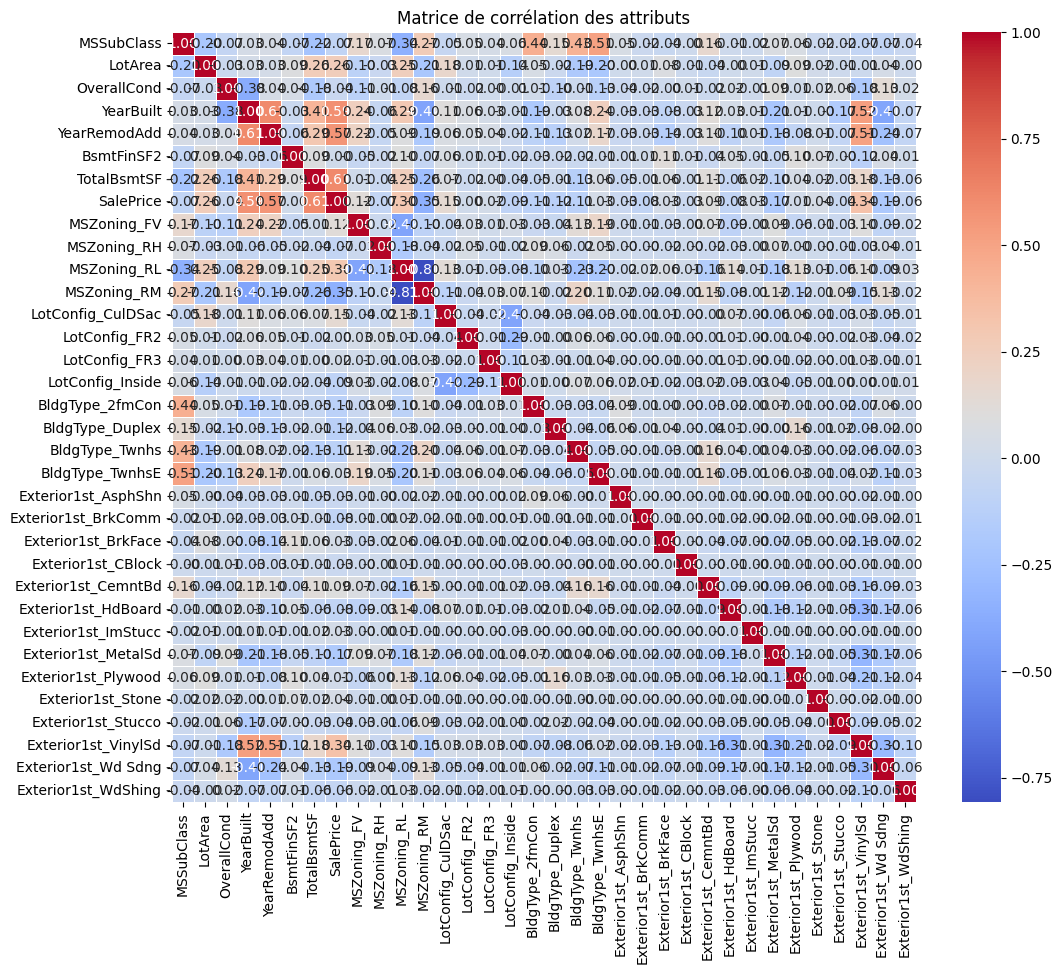

In [ ]:
display_corr_matrix(df)

#### 4.1.2 Question 11 (5 points)

On peut alors choisir de supprimer les attributs qui sont fortement corrélées entre eux en définissant un seuil. Fixons ce seuil à 0.7.

**Quels sont les attributs fortement correlés selon le critère ci-dessus ? Supprimez ces attributs et affichez la nouvelle matrice de corrélation.**

Paires d'attributs fortement corrélés (|corr| > 0.7):

Aucune colonne supprimée.
Afficher la matrice des colonnes restantes 


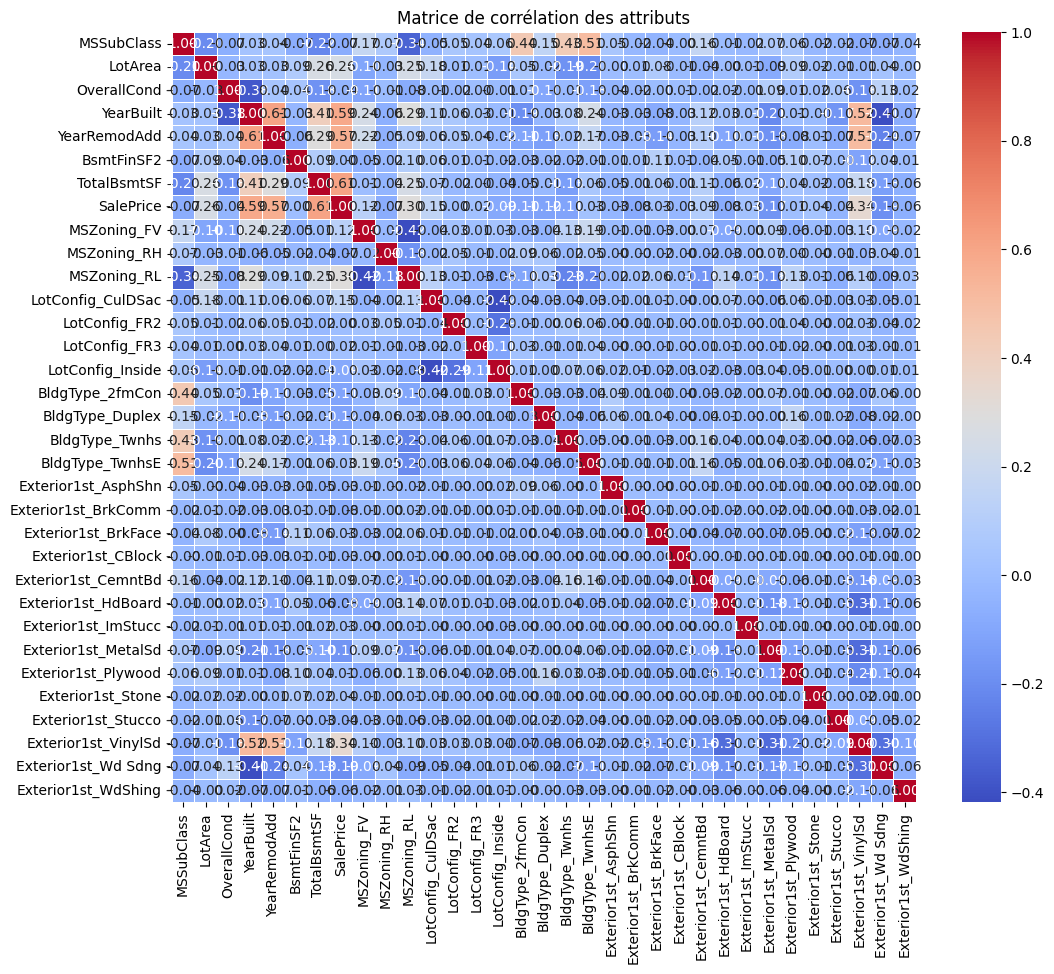

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def remove_highly_correlated_attributes(dataset, threshold=0.7):
    corr_matrix = dataset.corr().abs()

    columns_to_drop = set()

    print("Paires d'attributs fortement corrélés (|corr| > 0.7):")
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                colname_i = corr_matrix.columns[i]
                colname_j = corr_matrix.columns[j]
                print(f"{colname_i} et {colname_j}: {corr_matrix.iloc[i, j]:.2f}")
                columns_to_drop.add(colname_j)

    df_reduced = dataset.drop(columns=columns_to_drop)

    if columns_to_drop:
        print("\nColonnes supprimées:", list(columns_to_drop))
    else:
        print("\nAucune colonne supprimée.")

    return df_reduced

# Appliquer la fonction au dataset normalisé
df = remove_highly_correlated_attributes(df, threshold=0.7)

print("Afficher la matrice des colonnes restantes ")
display_corr_matrix(df)

## 5. Entrainement d'un modèle de régression linéaire (30 points)

### 5.1 Rappel du concept

La régression linéaire consiste à trouver une fonction affine qui minimise la somme des carrés des erreurs. La fonction affine est définie par la formule suivante :
$$ f(x) = \beta_0 + \beta_1^T x $$
Nous tentons de trouver les paramètres $\beta_0$ et $\beta_1$ qui minimisent $\sum_{i=1}^n (f(x_i) - y_i)^2=||y-X\beta||^2$ où $X$ est la matrice des données fournies au modèle et $y$ le vecteur des `SalePrice`.

On veut trouver le minimum de cette fonction. On va utiliser `RidgeRegression` de `sklearn` pour trouver les paramètres $\beta_0$ et $\beta_1$. Ce module utilise la méthode des moindres carrés (`numpy.linalg.lstsq`) pour trouver les paramètres $\beta_0$ et $\beta_1$.

### 5.2 Application

#### 5.2.1 Question 12 (5 points)

Après avoir effectué le prétraitement, on peut commencer par séparer les données en un ensemble d'entraînement et un ensemble de test. Pour cela, les 1460 premières lignes contiennent les données d'entrainement. On peut ainsi séparer les données en deux ensembles.

**Compléter la structure suivante afin de diviser les données en deux sous-ensembles.**

In [50]:
#TODO

data_train = {
    "x": df.iloc[:1460].drop(columns=['SalePrice']),
    "y": df.iloc[:1460]['SalePrice'],
    "df": df.iloc[:1460]
}

data_pred = {
    "x": df.iloc[1460:].drop(columns=['SalePrice']),
    "df": df.iloc[1460:]
}

#### 5.2.2 Question 13 (7.5 points)

Une fois cette séparation faite, on peut utiliser `RidgeRegression` pour effectuer la régression linéaire avec pénalisation de la norme L2.

**Compléter la fonction `ridge_regression`. Elle doit implémenter l'ensemble de la régression.**

*Pour cette question, vous devez retourner les coefficients de la regression linéaire. De plus, cette fonction doit modifier le paramètre `data_pred` en y ajoutant les valeurs prédites.*

**Remarques**:
- La fonction doit retourner un dictionnaire dont les clés sont les noms des attributs et les valeurs, les coefficients correspondants.
- Dans `data_pred`, ajoutez deux colonnes : une première contenant les prédictions (sortie du modèle), et une deuxième avec les prédictions remises à l’échelle originale des prix, en inversant la standardisation et la transformation logarithmique.

In [51]:
def ridge_regression(data_train, data_pred):
    """
    Réaliser la prédiction selon la régression de Rigde.

    :param data_train: données d'entrainement
    :param data_pred: données de prédiction

    :return:
      coefficients de la régression
    """

    model = linear_model.Ridge(alpha=1.0)

    model.fit(data_train['x'], data_train['y'])

    coefficients = dict(zip(data_train['x'].columns, model.coef_))

    predictions = model.predict(data_pred['x'])

    data_pred['y'] = predictions
    data_pred['df'].loc[:, 'Predicted_SalePrice_Log'] = predictions

    predictions_original_scale = np.exp(predictions * sigma_sale_price + mu_sale_price)
    data_pred['df'].loc[:, 'Predicted_SalePrice'] = predictions_original_scale

    return coefficients

In [52]:
 reg = ridge_regression(data_train, data_pred)
 data_pred["y"]

/tmp/ipython-input-1786529195.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_pred['df'].loc[:, 'Predicted_SalePrice_Log'] = predictions
/tmp/ipython-input-1786529195.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_pred['df'].loc[:, 'Predicted_SalePrice'] = predictions_original_scale


array([11.75104435, 11.97127568, 12.23850034, ..., 12.11341076,
       12.23166762, 12.1589803 ])

In [ ]:
reg

{'MSSubClass': np.float64(0.00432291348491963),
 'LotArea': np.float64(3.7511385631979404e-06),
 'OverallCond': np.float64(0.049097737429092986),
 'YearBuilt': np.float64(0.004638910536578968),
 'YearRemodAdd': np.float64(0.0038638561995575607),
 'BsmtFinSF2': np.float64(-6.280157552498459e-05),
 'TotalBsmtSF': np.float64(0.0004066427371463189),
 'MSZoning_FV': np.float64(0.15180904884799334),
 'MSZoning_RH': np.float64(0.10713623071637192),
 'MSZoning_RL': np.float64(0.12166287453871615),
 'LotConfig_CulDSac': np.float64(0.024714178353347653),
 'LotConfig_FR2': np.float64(-0.03614790011478417),
 'LotConfig_FR3': np.float64(0.028276434931016493),
 'LotConfig_Inside': np.float64(-0.01859892481677371),
 'BldgType_2fmCon': np.float64(-0.5673675133181768),
 'BldgType_Duplex': np.float64(-0.3083514746117107),
 'BldgType_Twnhs': np.float64(-0.6189871044993839),
 'BldgType_TwnhsE': np.float64(-0.47709419673923226),
 'Exterior1st_AsphShn': np.float64(0.07041283448094791),
 'Exterior1st_BrkComm

#### 5.2.3 Question 14 (5 points)

**À l’aide d’un histogramme, comparez la distribution des prix prédits à celle des données d’entraînement, en vous assurant que les deux sont représentées à l’échelle originale des prix (c’est-à-dire sans transformation logarithmique ni standardisation). Commentez brièvement.**

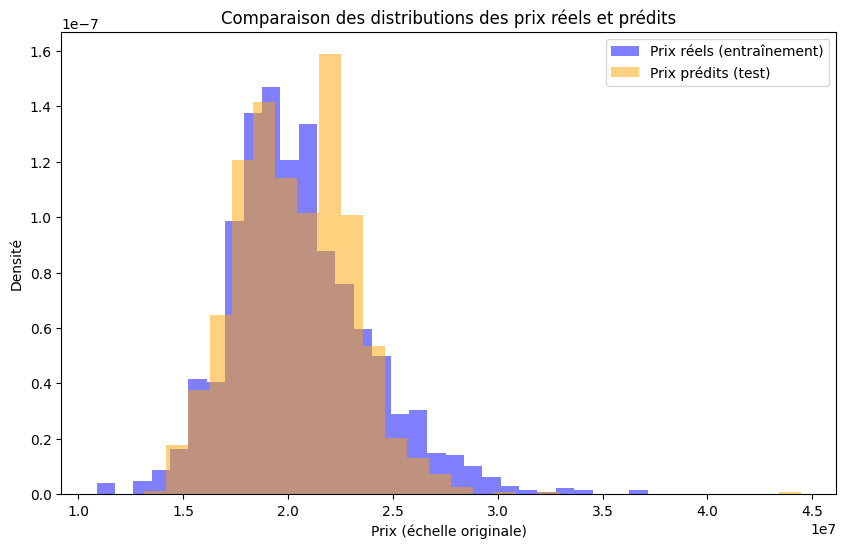

In [55]:
train_prices = np.expm1(data_train['y'] * sigma_sale_price + mu_sale_price)
pred_prices = np.expm1(data_pred['y'] * sigma_sale_price + mu_sale_price)

# Extraire les prix prédits (Predicted_SalePrice) de l'ensemble de test, déjà à l'échelle originale
pred_prices = data_pred['df']['Predicted_SalePrice']

# Créer un histogramme pour comparer les distributions
plt.figure(figsize=(10, 6))
plt.hist(train_prices, bins=30, alpha=0.5, color='blue', label='Prix réels (entraînement)', density=True)
plt.hist(pred_prices, bins=30, alpha=0.5, color='orange', label='Prix prédits (test)', density=True)

# Ajouter des labels et un titre
plt.xlabel('Prix (échelle originale)')
plt.ylabel('Densité')
plt.title('Comparaison des distributions des prix réels et prédits')
plt.legend()

# Afficher le graphique
plt.show()


Commenter:


### 5.3. Sélection des attributs importants
#### 5.3.1 Question 15 (5 points)

Une fois la prédiction obtenue, on peut maintenant mesurer l'importance de chaque attribut dans la prédicition en traçant les coefficients de la régression linéaire.

**Quels sont les dix attributs ayant le plus d'impact dans la prédiction ?**


Les 10 attributs ayant le plus d'impact dans la prédiction :
                 Coefficient
MSSubClass          0.198041
TotalBsmtSF         0.180323
YearBuilt           0.139730
BldgType_TwnhsE    -0.138050
BldgType_Twnhs     -0.120379
BldgType_2fmCon    -0.091604
YearRemodAdd        0.079663
BldgType_Duplex    -0.063559
OverallCond         0.053015
MSZoning_RL         0.050367


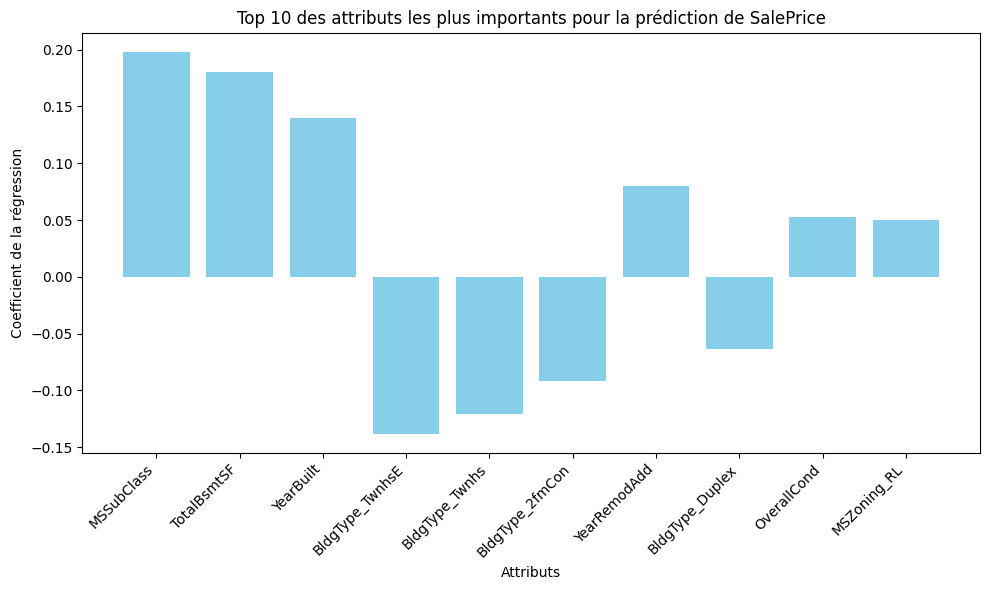

In [56]:
coef_df = pd.DataFrame.from_dict(reg, orient='index', columns=['Coefficient'])
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

top_10_coef = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(10)

print("Les 10 attributs ayant le plus d'impact dans la prédiction :")
print(top_10_coef[['Coefficient']])

plt.figure(figsize=(10, 6))
plt.bar(top_10_coef.index, top_10_coef['Coefficient'], color='skyblue')
plt.xlabel('Attributs')
plt.ylabel('Coefficient de la régression')
plt.title('Top 10 des attributs les plus importants pour la prédiction de SalePrice')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 5.3.2 Question 16 (7.5 points)

Cette dernière méthode n'est pas nécessairement une bonne mesure de l'importance d'un attribut. On peut utiliser la méthode SHAP (SHapley Additive exPlanations) pour effectuer la sélection des attributs.

**Les dix attributs ayant le plus d'impact dans la prédiction pour cette mesure sont-ils les mêmes que ceux de la question précédente ? Donnez une interprétation comparative de ces deux résultats**


In [62]:
ridge_model = linear_model.Ridge().fit(data_train["x"], data_train["y"])
explainer = shap.Explainer(ridge_model, data_train["x"])
shap_values = explainer(data_train["x"])

shap_importance = np.abs(shap_values.values).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature': data_train["x"].columns,
    'SHAP_Importance': shap_importance
})

top_10_shap = shap_df.sort_values(by='SHAP_Importance', ascending=False).head(10)
print("Top 10 variables selon SHAP :")
print(top_10_shap)

coef_df = pd.DataFrame({
    'Feature': data_train["x"].columns,
    'Coefficient': ridge_model.coef_
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top_10_coef = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(10)
print("\nTop 10 variables selon coefficients absolus :")
print(top_10_coef)

Top 10 variables selon SHAP :
            Feature  SHAP_Importance
0        MSSubClass         0.145644
6       TotalBsmtSF         0.131941
3         YearBuilt         0.115664
4      YearRemodAdd         0.071613
17  BldgType_TwnhsE         0.066287
2       OverallCond         0.040686
16   BldgType_Twnhs         0.038898
9       MSZoning_RL         0.038182
15  BldgType_Duplex         0.027480
14  BldgType_2fmCon         0.025631

Top 10 variables selon coefficients absolus :
            Feature  Coefficient  Abs_Coefficient
0        MSSubClass     0.198041         0.198041
6       TotalBsmtSF     0.180323         0.180323
3         YearBuilt     0.139730         0.139730
17  BldgType_TwnhsE    -0.138050         0.138050
16   BldgType_Twnhs    -0.120379         0.120379
14  BldgType_2fmCon    -0.091604         0.091604
4      YearRemodAdd     0.079663         0.079663
15  BldgType_Duplex    -0.063559         0.063559
2       OverallCond     0.053015         0.053015
9       MSZoning

## 6. Méthode des écarts interquartiles ou IRQ (10 points)

On peut également détecter les valeurs aberrantes en affichant un boxplot de chaque colonne. On considère les valeurs comme aberrantes si elles sont situées en dehors de l'intervalle [Q1 - α * IQR, Q3 + α * IQR] où
* Q1 et Q3 sont les quantiles 25% et 75%,
* IQR l'intervalle interquartile (Q3 - Q1)
* α le facteur d'ajustement.

Pour cette question, on exclut `SalePrice` car les seules valeurs manquantes de cet attribut sont celles du dataset de test.

**Important :** Pour cette question, utilisez le jeux de données `df_order1` copié vers la fin de la section 2.

### 6.1 Question 17 (5 points)

Testez plusieurs valeurs du facteur d'ajustement α dans l'intervalle [1.5, 5] avec un pas de 0.5.
Pour chaque valeur de α :
- Calculez les bornes de détection des valeurs aberrantes (fences) pour chaque attribut numérique.
- Déterminez le nombre de valeurs aberrantes détectées pour chaque attribut.
- Affichez les résultats dans un `DataFrame`, où les lignes correspondent aux différentes valeurs de α et les colonnes correspondent aux attributs numériques.

**Remarque :** Vous pouvez utiliser la fonction `percentile` de `numpy` pour calculer les quantiles.

In [ ]:
import pandas as pd
import numpy as np

# Fonction pour détecter les valeurs aberrantes avec IQR
def detect_outliers_iqr(df, alpha_values, numeric_columns):
    """
    Détecte les valeurs aberrantes pour chaque attribut numérique avec différentes valeurs de alpha.

    :param df: DataFrame contenant les données
    :param alpha_values: Liste des valeurs de alpha à tester
    :param numeric_columns: Liste des colonnes numériques à analyser
    :return: DataFrame avec le nombre de valeurs aberrantes par attribut et par alpha
    """
    results = pd.DataFrame(index=alpha_values, columns=numeric_columns)

    for alpha in alpha_values:
        outliers_count = {}
        for col in numeric_columns:
            Q1 = np.percentile(df[col].dropna(), 25)
            Q3 = np.percentile(df[col].dropna(), 75)
            IQR = Q3 - Q1

            lower_bound = Q1 - alpha * IQR
            upper_bound = Q3 + alpha * IQR

            outliers = df[col][(df[col] < lower_bound) | (df[col] > upper_bound)]
            outliers_count[col] = len(outliers)

        results.loc[alpha] = outliers_count

    return results

numeric_columns = [col for col in df_order1.select_dtypes(include=['int64', 'float64']).columns if col != 'SalePrice']

alpha_values = np.arange(1.5, 5.1, 0.5)

outliers_df = detect_outliers_iqr(df_order1, alpha_values, numeric_columns)


print("Nombre de valeurs aberrantes par attribut et par valeur de α :")
print(outliers_df)

Nombre de valeurs aberrantes par attribut et par valeur de α :
    MSSubClass LotArea OverallCond YearBuilt YearRemodAdd BsmtFinSF2  \
1.5        207     125         250         9            0        347   
2.0         78      92          57         0            0        347   
2.5          0      67          57         0            0        347   
3.0          0      51           6         0            0        347   
3.5          0      41           6         0            0        347   
4.0          0      35           0         0            0        347   
4.5          0      34           0         0            0        347   
5.0          0      31           0         0            0        347   

    TotalBsmtSF  
1.5         119  
2.0          22  
2.5          10  
3.0           7  
3.5           6  
4.0           2  
4.5           2  
5.0           2  


Visualisez les résultats dans une seule figure:
- L’axe X représente les valeurs de α.
- L’axe Y représente le nombre de valeurs aberrantes.
- Chaque courbe correspond à un attribut numérique, illustrant l’évolution du nombre de valeurs aberrantes en fonction de α.

Quelle valeur de α vous semble le mieux adaptée? Justifiez votre réponse.

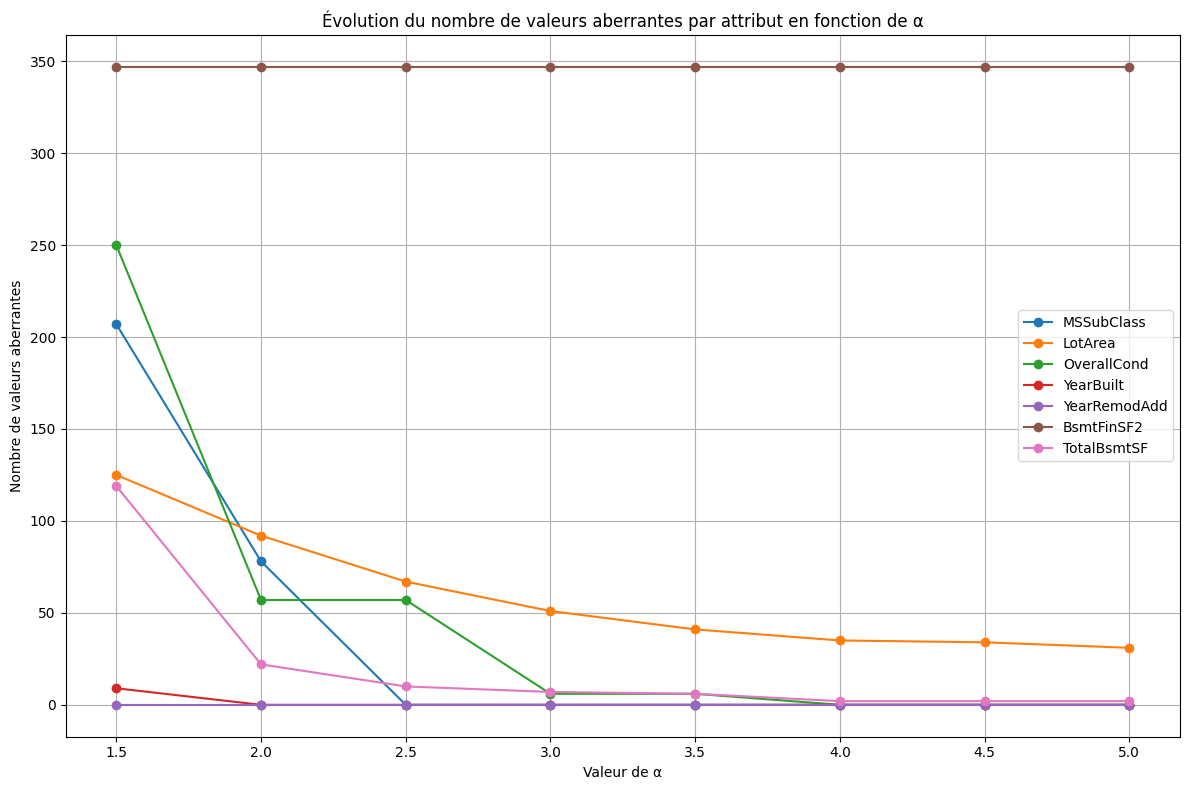

In [ ]:
# Visualiser les résultats dans une seule figure
plt.figure(figsize=(12, 8))
for col in numeric_columns:
    plt.plot(alpha_values, outliers_df[col], marker='o', label=col)

# Ajouter des labels et un titre
plt.xlabel('Valeur de α')
plt.ylabel('Nombre de valeurs aberrantes')
plt.title('Évolution du nombre de valeurs aberrantes par attribut en fonction de α')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


On fixe α = 3.0.

À α = 1.5, trop de valeurs aberrantes sont détectées, ce qui peut conduire à l’élimination de données pertinentes.

À α = 3.0, le nombre de valeurs aberrantes diminue considérablement, tout en conservant celles qui sont véritablement inhabituelles. Cette valeur permet ainsi d’éviter une suppression excessive des données, tout en protégeant le modèle de régression contre les points extrêmement atypiques.

En revanche, une valeur plus élevée (par exemple α = 5.0) détecte très peu de valeurs aberrantes, ce qui risque de laisser subsister des erreurs importantes.

### 6.2 Question 18 (5 points)

**On  fixe le facteur d'ajustement α à `3` pour tous les attributs.**

Pour chaque attribut numérique, tracez un boxplot. Ajoutez également deux lignes horizontales représentant les bornes inférieure et supérieure de l’intervalle [Q1 - α * IQR, Q3 + α * IQR].

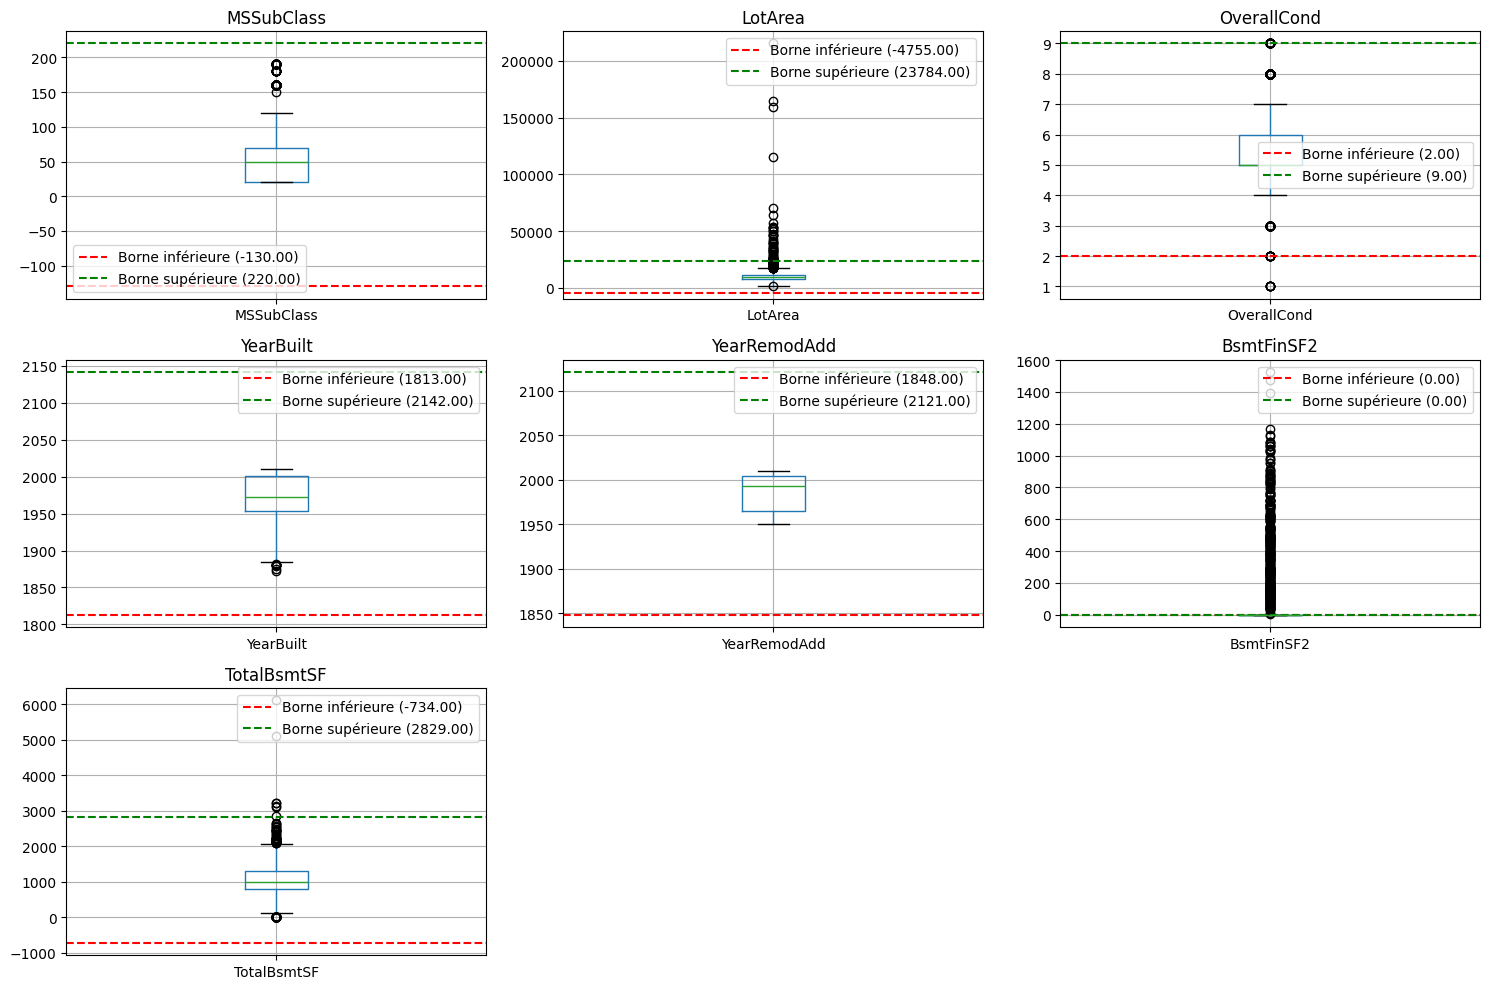

In [ ]:
#TODO

alpha = 3

def calculate_bounds(df, column, alpha): # Fonction pour calculer les bornes
    Q1 = np.percentile(df[column].dropna(), 25)
    Q3 = np.percentile(df[column].dropna(), 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - alpha * IQR
    upper_bound = Q3 + alpha * IQR
    return lower_bound, upper_bound

numeric_columns = [col for col in df_order1.select_dtypes(include=['int64', 'float64']).columns if col != 'SalePrice']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    lower_bound, upper_bound = calculate_bounds(df_order1, col, alpha)
    df_order1.boxplot(column=[col])
    plt.axhline(y=lower_bound, color='r', linestyle='--', label=f'Borne inférieure ({lower_bound:.2f})')
    plt.axhline(y=upper_bound, color='g', linestyle='--', label=f'Borne supérieure ({upper_bound:.2f})')
    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

Pour chaque attribut numérique (à l'exception de `BsmtFinSF2`), remplacez les valeurs aberrantes détectées avec α=3 par la `valeur médiane` de la colonne. Pourquoi ce remplacement n’est pas approprié pour l’attribut `BsmtFinSF2` ?

In [ ]:
def process_outliers(df, column, alpha):
    Q1 = np.percentile(df[column].dropna(), 25)
    Q3 = np.percentile(df[column].dropna(), 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - alpha * IQR
    upper_bound = Q3 + alpha * IQR
    outliers = df[column][(df[column] < lower_bound) | (df[column] > upper_bound)].index
    median_value = df[column].median()
    if column != 'BsmtFinSF2':
        df.loc[outliers, column] = median_value
    return df

# Appliquer le remplacement pour chaque attribut numérique
for col in numeric_columns:
    df_abe = process_outliers(df_order1, col, alpha)

print("Premières lignes de df_order1 après remplacement :")
print(df_order1.head())

Premières lignes de df_order1 après remplacement :
   MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  YearBuilt  \
0          60       RL     8450    Inside     1Fam            5       2003   
1          20       RL     9600       FR2     1Fam            8       1976   
2          60       RL    11250    Inside     1Fam            5       2001   
3          70       RL     9550    Corner     1Fam            5       1915   
4          60       RL    14260       FR2     1Fam            5       2000   

   YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0          2003     VinylSd         0.0        856.0  12.247694  
1          1976     MetalSd         0.0       1262.0  12.109011  
2          2002     VinylSd         0.0        920.0  12.317167  
3          1970     Wd Sdng         0.0        756.0  11.849398  
4          2000     VinylSd         0.0       1145.0  12.429216  


In [ ]:
df_order1["BsmtFinSF2"]

,BsmtFinSF2
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
2914,0.0
2915,0.0
2916,0.0
2917,0.0


Le remplacement des valeurs aberrantes par la médiane n’est pas approprié pour BsmtFinSF2, car cet attribut peut inclure des valeurs nulles.

Ces zéros risquent d’être considérés à tort comme aberrants si la distribution est décalée (par exemple lorsque la médiane est positive). Les remplacer par la médiane introduirait un biais, en suggérant artificiellement une surface là où il n’y en a pas. Il est donc préférable de conserver ces valeurs ou d’utiliser une méthode spécifique, comme leur substitution par 0 ou par une valeur contextuellement justifiée.